In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import timm
from xgboost import XGBClassifier


In [ ]:
# Fungsi Visualisasi
def tampilkan_confusion_matrix(y_true, y_pred, judul):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Cataract'],
                yticklabels=['Normal', 'Cataract'])
    plt.xlabel('Prediksi Model')
    plt.ylabel('Kenyataan (Ground Truth)')
    plt.title(f'Confusion Matrix: {judul}')
    plt.show()

In [ ]:
# Definisikan Class Dataset
class MataDataset(Dataset):
    def __init__(self, dataframe, train_dir, test_dir, transform=None):
        self.dataframe = dataframe
        self.train_dir = train_dir
        self.test_dir = test_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        file_name = self.dataframe.iloc[idx, 0]

        # Logika mencari file: Cek di folder training, jika tidak ada cek di testing
        img_path = os.path.join(self.train_dir, file_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(self.test_dir, file_name)

        image = Image.open(img_path).convert('RGB')
        label = int(self.dataframe.iloc[idx, 2])

        if self.transform:
            image = self.transform(image)
        return image, label

# **Persiapan Data**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Tentukan Path
path_excel = '/content/drive/MyDrive/SKRIPSI/Dataset/data.xlsx'
train_folder = '/content/drive/MyDrive/SKRIPSI/Dataset/Training Images/'
test_folder = '/content/drive/MyDrive/SKRIPSI/Dataset/Testing Images/'

# 2. Load & Filter (Bentuk df_final)
df_raw = pd.read_excel(path_excel)
left = df_raw[['Left-Fundus', 'Left-Diagnostic Keywords']].rename(columns={'Left-Fundus':'file', 'Left-Diagnostic Keywords':'label_raw'})
right = df_raw[['Right-Fundus', 'Right-Diagnostic Keywords']].rename(columns={'Right-Fundus':'file', 'Right-Diagnostic Keywords':'label_raw'})
df_final = pd.concat([left, right], ignore_index=True)
df_final = df_final[df_final['label_raw'].str.contains('cataract|normal', case=False, na=False)].copy()
df_final['label'] = df_final['label_raw'].apply(lambda x: 1 if 'cataract' in x.lower() else 0)

In [ ]:
# Total data
print("--- TOTAL DATA setelah filter ---")
print(df_final['label_raw'].value_counts())

--- TOTAL DATA setelah filter ---
label_raw
normal fundus                                                              2816
cataract                                                                    262
lens dust，normal fundus                                                     222
normal fundus，lens dust                                                      55
cataract，lens dust                                                           14
lens dust，cataract                                                           10
cataract，moderate non proliferative retinopathy                               6
moderate non proliferative retinopathy，cataract                               4
cataract，mild nonproliferative retinopathy                                    3
hypertensive retinopathy，cataract                                             3
cataract，suspected glaucoma                                                   2
normal fundus，normal fundus                                                 

# **Oversampling**

In [ ]:
# 3. Split & Oversampling (Bentuk df_train dan df_test)
from sklearn.model_selection import train_test_split
df_train_raw, df_test = train_test_split(df_final, test_size=0.2, random_state=42, stratify=df_final['label'])

# Proses Oversampling (oversampling hanya pada Data Training)
df_normal = df_train_raw[df_train_raw['label'] == 0]
df_cataract = df_train_raw[df_train_raw['label'] == 1]
df_cataract_over = df_cataract.sample(len(df_normal), replace=True, random_state=42)
df_train = pd.concat([df_normal, df_cataract_over], ignore_index=True)

print(f"Total data Training (setelah Oversampling): {len(df_train)}")
print(df_train['label'].value_counts().rename({0: 'Normal', 1: 'Cataract'}))

print("\nTotal data Testing (Original): {len(df_test)}")
print(df_test['label'].value_counts().rename({0: 'Normal', 1: 'Cataract'}))

Total data Training (setelah Oversampling): 4966
label
Normal      2483
Cataract    2483
Name: count, dtype: int64

Total data Testing (Original): {len(df_test)}
label
Normal      621
Cataract     63
Name: count, dtype: int64


In [ ]:
transform_ops = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Buat Dataset & Loader (Gunakan df_train dan df_test yang sudah jadi)
train_dataset = MataDataset(df_train, train_folder, test_folder, transform=transform_ops)
test_dataset = MataDataset(df_test, train_folder, test_folder, transform=transform_ops)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# **Fine-Tuning ViT Murni)**

In [ ]:
transform_ops = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(MataDataset(df_train, train_folder, test_folder, transform_ops), batch_size=16, shuffle=True)
test_loader = DataLoader(MataDataset(df_test, train_folder, test_folder, transform_ops), batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2).to(device)
optimizer = torch.optim.Adam(model_vit.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
import torchvision.transforms as transforms
import timm
import torch.nn as nn
import torch
from torch.utils.data import DataLoader

transform_ops = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(MataDataset(df_train, train_folder, test_folder, transform_ops), batch_size=16, shuffle=True)
test_loader = DataLoader(MataDataset(df_test, train_folder, test_folder, transform_ops), batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2).to(device)
optimizer = torch.optim.Adam(model_vit.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Inisialisasi list untuk menampung history
history_train_loss = []
history_val_loss = []
best_val_loss = float('inf')
best_epoch = 0

In [ ]:
for epoch in range(6):
    # --- FASE TRAINING ---
    model_vit.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_vit(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    # --- FASE VALIDASI (Melihat Konvergensi) ---
    model_vit.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_vit(images)
            v_loss = criterion(outputs, labels)
            running_val_loss += v_loss.item()

    avg_val_loss = running_val_loss / len(test_loader)
    history_val_loss.append(avg_val_loss)

    # Catat Epoch Terbaik
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        # Simpan model terbaik agar bisa dipanggil nanti
        torch.save(model_vit.state_dict(), 'best_vit_model.pth')

    print(f"Epoch [{epoch+1}/5] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print(f"\nTraining Selesai! Konvergensi tercapai pada Epoch ke-{best_epoch}")

Epoch [1/5] - Train Loss: 0.1098 | Val Loss: 0.0634
Epoch [2/5] - Train Loss: 0.0287 | Val Loss: 0.1113
Epoch [3/5] - Train Loss: 0.0159 | Val Loss: 0.1025
Epoch [4/5] - Train Loss: 0.0073 | Val Loss: 0.1488
Epoch [5/5] - Train Loss: 0.0001 | Val Loss: 0.1563
Epoch [6/5] - Train Loss: 0.0000 | Val Loss: 0.1652

Training Selesai! Konvergensi tercapai pada Epoch ke-1



--- HASIL EVALUASI FINAL ViT MURNI ---
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       621
    Cataract       0.93      0.84      0.88        63

    accuracy                           0.98       684
   macro avg       0.96      0.92      0.94       684
weighted avg       0.98      0.98      0.98       684



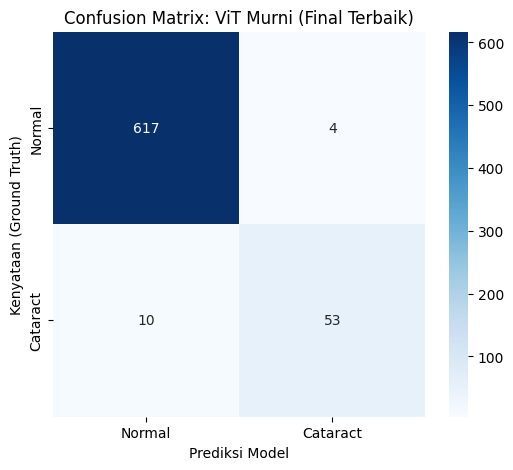

In [ ]:
# 1. Memanggil kembali kondisi 'otak' model yang paling pintar
model_vit.load_state_dict(torch.load('best_vit_model.pth'))
model_vit.eval() # Mengatur model ke mode evaluasi (ujian)

y_true, y_pred, y_probs = [], [], []

# 2. Proses pengujian pada data testing tanpa menghitung gradien (hemat memori)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Mendapatkan output mentah (logits)
        outputs = model_vit(images)

        # PERBAIKAN: Menghitung probabilitas (0-100%) untuk setiap kelas
        probs = torch.softmax(outputs, dim=1)

        # Menentukan prediksi akhir (ambil angka dengan skor tertinggi)
        _, preds = torch.max(outputs, 1)

        # Menyimpan hasil untuk keperluan statistik
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Menyimpan probabilitas khusus untuk kelas 'Cataract' (index 1)
        # Ini sangat berguna untuk grafik ROC-AUC di Skripsi
        y_probs.extend(probs.cpu().numpy()[:, 1])

# 3. Menampilkan Laporan Klasifikasi (Precision, Recall, F1-Score)
print("\n--- HASIL EVALUASI FINAL ViT MURNI ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Cataract']))

# 4. Menampilkan Confusion Matrix
tampilkan_confusion_matrix(y_true, y_pred, "ViT Murni (Final Terbaik)")

In [ ]:
# ============================================
# ANALISIS DAMPAK "LENS DUST" TERHADAP MODEL
# ============================================

print("="*60)
print("ANALISIS SUBGROUP: DAMPAK LABEL 'LENS DUST'")
print("="*60)

# 1. Identifikasi indeks sampel yang mengandung 'lens dust' di test set
# Reset index df_test agar bisa dilacak
df_test_reset = df_test.reset_index(drop=True)

# Simpan prediksi dan label asli dalam dataframe analisis
df_analysis = pd.DataFrame({
    'file': df_test_reset['file'],
    'label_raw': df_test_reset['label_raw'],
    'label_true': y_true,
    'label_pred': y_pred
})

# 2. Filter sampel yang mengandung 'lens dust'
df_lens_dust = df_analysis[
    df_analysis['label_raw'].str.contains('lens dust', case=False, na=False)
]

# 3. Filter sampel TANPA 'lens dust'
df_no_lens_dust = df_analysis[
    ~df_analysis['label_raw'].str.contains('lens dust', case=False, na=False)
]

# 4. Analisis performa pada subgroup lens dust
print(f"\n📊 SUBGROUP 'LENS DUST' (n={len(df_lens_dust)}):")
print(f"   - Distribusi label: {df_lens_dust['label_true'].value_counts().to_dict()}")
print(f"   - Salah prediksi: {(df_lens_dust['label_true'] != df_lens_dust['label_pred']).sum()} sampel")
print(f"   - Akurasi: {(df_lens_dust['label_true'] == df_lens_dust['label_pred']).mean():.4f}")

if len(df_lens_dust) > 0:
    # Tampilkan detail sampel yang salah prediksi
    df_lens_dust_wrong = df_lens_dust[df_lens_dust['label_true'] != df_lens_dust['label_pred']]
    print(f"\n   ❌ Detail sampel 'lens dust' yang SALAH prediksi ({len(df_lens_dust_wrong)} sampel):")
    for idx, row in df_lens_dust_wrong.iterrows():
        true_label = "Cataract" if row['label_true'] == 1 else "Normal"
        pred_label = "Cataract" if row['label_pred'] == 1 else "Normal"
        print(f"      - File: {row['file']} | Label Asli: {true_label} | Diprediksi: {pred_label} | Raw: {row['label_raw']}")

# 5. Analisis performa pada subgroup TANPA lens dust
print(f"\n📊 SUBGROUP TANPA 'LENS DUST' (n={len(df_no_lens_dust)}):")
print(f"   - Salah prediksi: {(df_no_lens_dust['label_true'] != df_no_lens_dust['label_pred']).sum()} sampel")
print(f"   - Akurasi: {(df_no_lens_dust['label_true'] == df_no_lens_dust['label_pred']).mean():.4f}")

# 6. Bandingkan performa
print("\n📈 PERBANDINGAN AKURASI:")
print(f"   - Subgroup 'Lens Dust' : {(df_lens_dust['label_true'] == df_lens_dust['label_pred']).mean():.4f}")
print(f"   - Subgroup Tanpa 'Lens Dust': {(df_no_lens_dust['label_true'] == df_no_lens_dust['label_pred']).mean():.4f}")
print(f"   - Selisih           : {abs((df_lens_dust['label_true'] == df_lens_dust['label_pred']).mean() - (df_no_lens_dust['label_true'] == df_no_lens_dust['label_pred']).mean()):.4f}")

# 7. Analisis False Positive dari kelas Normal
fp_mask = (df_analysis['label_true'] == 0) & (df_analysis['label_pred'] == 1)
df_fp = df_analysis[fp_mask]
print(f"\n🔍 ANALISIS FALSE POSITIVE (Normal → Cataract):")
print(f"   - Total FP: {len(df_fp)}")
fp_lens_dust = df_fp[df_fp['label_raw'].str.contains('lens dust', case=False, na=False)]
print(f"   - FP yg mengandung 'lens dust': {len(fp_lens_dust)} ({len(fp_lens_dust)/max(len(df_fp),1)*100:.1f}%)")
if len(fp_lens_dust) > 0:
    print("   - Detail FP 'lens dust':")
    for idx, row in fp_lens_dust.iterrows():
        print(f"      → {row['file']}: {row['label_raw']}")

# 8. Analisis False Negative dari kelas Cataract
fn_mask = (df_analysis['label_true'] == 1) & (df_analysis['label_pred'] == 0)
df_fn = df_analysis[fn_mask]
print(f"\n🔍 ANALISIS FALSE NEGATIVE (Cataract → Normal):")
print(f"   - Total FN: {len(df_fn)}")
fn_lens_dust = df_fn[df_fn['label_raw'].str.contains('lens dust', case=False, na=False)]
print(f"   - FN yg mengandung 'lens dust': {len(fn_lens_dust)} ({len(fn_lens_dust)/max(len(df_fn),1)*100:.1f}%)")
if len(fn_lens_dust) > 0:
    print("   - Detail FN 'lens dust':")
    for idx, row in fn_lens_dust.iterrows():
        print(f"      → {row['file']}: {row['label_raw']}")

ANALISIS SUBGROUP: DAMPAK LABEL 'LENS DUST'


NameError: name 'df_test' is not defined

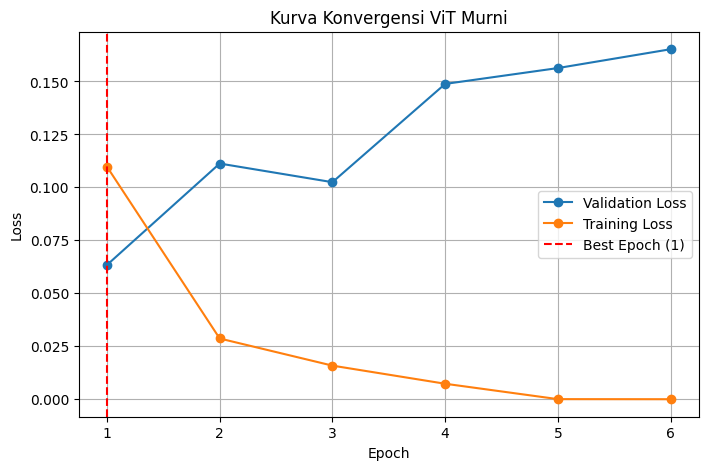

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, marker='o', label='Validation Loss')
plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, marker='o', label='Training Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Kurva Konvergensi ViT Murni')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

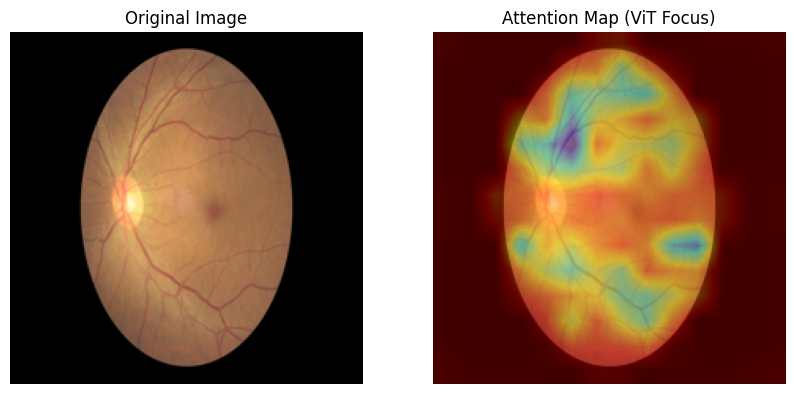

In [ ]:
import cv2
import types

def visualize_attention(model, img_path, transform, device):
    # 1. Preprocessing Gambar
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    # 2. Ambil Atensi dari Layer Terakhir
    # 'vit_base_patch16_224' di library timm menyimpan atensi di blocks
    model.eval()
    attentions = []

    # Store the original forward method of the Attention module
    original_attention_forward = model.blocks[-1].attn.forward

    # Define a new forward method for the Attention module to capture attention weights
    # Include attn_mask and is_causal as they might be passed by the timm Block's forward method
    def new_attention_forward(self, x, attn_mask=None, is_causal=False):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]   # make torchscript happy (cannot use tensor as tuple)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        # Capture attention weights here (before dropout and projection)
        attentions.append(attn.clone()) # Clone to avoid in-place modification issues

        # Now apply the rest of the original forward pass
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

    # Temporarily replace the forward method
    model.blocks[-1].attn.forward = types.MethodType(new_attention_forward, model.blocks[-1].attn)

    with torch.no_grad():
        _ = model(input_tensor)

    # Restore the original forward method after use
    model.blocks[-1].attn.forward = original_attention_forward

    # 3. Proses Matriks Atensi
    # attentions will contain one tensor of shape (batch_size, num_heads, num_patches, num_patches)
    # For batch_size=1, attentions[0] is (1, num_heads, num_patches, num_patches)
    attn_mat = attentions[0].cpu().numpy()
    # Average across heads (axis=1) and reshape to (num_patches, num_patches)
    attn_mat = np.mean(attn_mat, axis=1).reshape(-1, attn_mat.shape[-1])

    # Menghitung residual dan rollout sederhana
    res_attn = attn_mat + np.eye(attn_mat.shape[1])
    res_attn = res_attn / res_attn.sum(axis=-1)[..., None]

    # Ambil atensi dari token [CLS] ke seluruh patch
    # The first row/column corresponds to the CLS token, so we take res_attn[0, 1:]
    cls_attn = res_attn[0, 1:]

    # Reshape menjadi grid (14x14 for 224x224 image with patch 16)
    dim = int(np.sqrt(cls_attn.shape[0]))
    mask = cls_attn.reshape(dim, dim)

    # 4. Plotting
    mask = cv2.resize(mask / mask.max(), (224, 224))
    mask = np.uint8(255 * mask)
    heatmap = cv2.applyColorMap(mask, cv2.COLORMAP_JET)

    # Gabungkan dengan gambar asli
    img_array = np.array(image.resize((224, 224)))
    result = cv2.addWeighted(img_array, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img_array)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Attention Map (ViT Focus)")
    plt.imshow(result)
    plt.axis('off')
    plt.show()

#attention map
sample_path = "/content/drive/MyDrive/SKRIPSI/Dataset/Training Images/1_left.jpg"
visualize_attention(model_vit, sample_path, transform_ops, device)

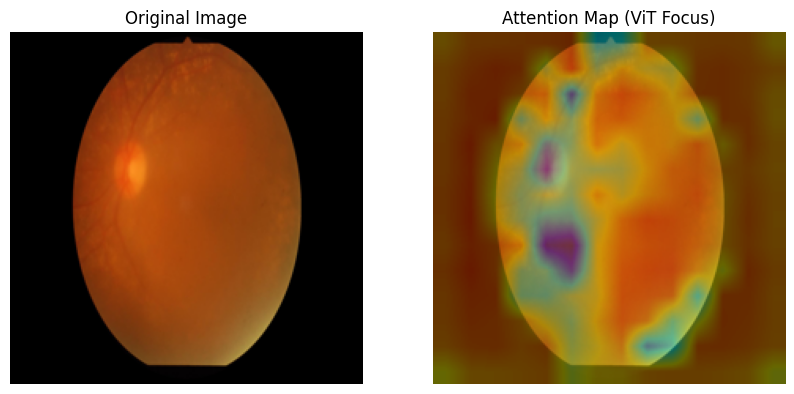

In [ ]:
sample_path = "/content/drive/MyDrive/SKRIPSI/Dataset/Training Images/465_left.jpg"
visualize_attention(model_vit, sample_path, transform_ops, device)

# **Hybrid**


--- HASIL EVALUASI HYBRID ViT-XGBOOST ---
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       621
    Cataract       0.87      0.83      0.85        63

    accuracy                           0.97       684
   macro avg       0.92      0.91      0.92       684
weighted avg       0.97      0.97      0.97       684



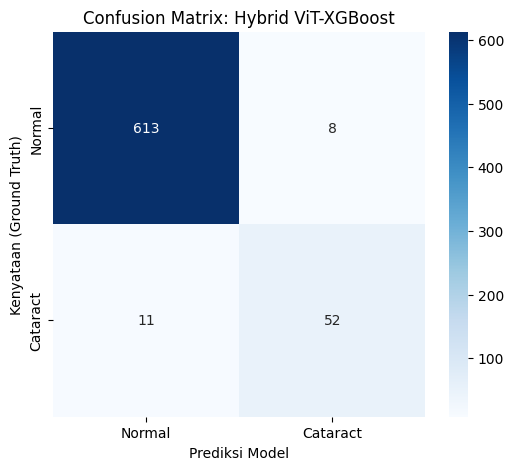

In [ ]:
# Preparing cell for re-execution
# 1. Load Model Terbaik & Potong Classifier Head

# Re-initialize the model to ensure a clean state
model_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2).to(device)

model_vit.load_state_dict(torch.load('best_vit_model.pth'))
model_vit.reset_classifier(0) # ViT sekarang hanya ekstraktor fitur
model_vit.eval()

# 2. Ekstraksi & Simpan Fitur (Format .npy)
def get_features(loader):
    feats, lbls = [], []
    with torch.no_grad():
        for img, lbl in loader:
            out = model_vit(img.to(device))
            feats.append(out.cpu().numpy())
            lbls.append(lbl.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

X_train, y_train_xgb = get_features(train_loader)
X_test, y_test_xgb = get_features(test_loader)

# Simpan ke Drive
np.save('/content/drive/MyDrive/SKRIPSI/X_train_features.npy', X_train)
np.save('/content/drive/MyDrive/SKRIPSI/X_test_features.npy', X_test)

# 3. Klasifikasi XGBoost
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
xgb_model.fit(X_train, y_train_xgb)

# 4. Evaluasi Final Hybrid
y_pred_hybrid = xgb_model.predict(X_test)
print("\n--- HASIL EVALUASI HYBRID ViT-XGBOOST ---")
print(classification_report(y_test_xgb, y_pred_hybrid, target_names=['Normal', 'Cataract']))
tampilkan_confusion_matrix(y_test_xgb, y_pred_hybrid, "Hybrid ViT-XGBoost")

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

# 5. K-FOLD CROSS-VALIDATION (ROBUSTNESS CHECK)
# Menggabungkan fitur dari train dan test untuk validasi menyeluruh
X_all = np.vstack((X_train, X_test))
y_all = np.concatenate((y_train_xgb, y_test_xgb))

# Mendefinisikan 5-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Menjalankan validasi pada model XGBoost yang sudah didefinisikan sebelumnya
# Kita menggunakan metrik 'accuracy' agar bisa dibandingkan dengan ViT Murni
cv_scores = cross_val_score(xgb_model, X_all, y_all, cv=kfold, scoring='accuracy')

print(f"--- VALIDASI STABILITAS (5-FOLD CV) ---")
print(f"Skor Akurasi tiap Fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f} \u00B1 {cv_scores.std():.4f}")

--- VALIDASI STABILITAS (5-FOLD CV) ---
Skor Akurasi tiap Fold: [0.99380531 0.99823009 0.99646018 0.99380531 0.99557522]
Mean Accuracy: 0.9956 ± 0.0017
